# Wine Quality Classification — Combined Red & White Dataset

End-to-end classification pipeline covering dataset audit, EDA, cleaning, feature engineering, preprocessing, all 5 required classification algorithms (Part A), comparison table.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

sns.set_style('whitegrid')
sns.set_palette('colorblind')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("wine-quality-white-and-red.csv")
print('Loaded dataset shape:', df.shape)
df.head()


Loaded dataset shape: (6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 2. Dataset Audit

In [2]:
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isna().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print('Wine type counts:')
print(df['type'].value_counts())
print()
print('Original quality (target) distribution:')
print(df['quality'].value_counts().sort_index())
display(df.describe().T)


Shape: (6497, 13)

Data types:
type                     object
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values per column:
type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 1177

Wine type counts:
type
white    4898
red      1599
Name: count, dtype: int64

Original quality (target) distribution:
quality
3      30
4

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## 3. EDA Visualisations

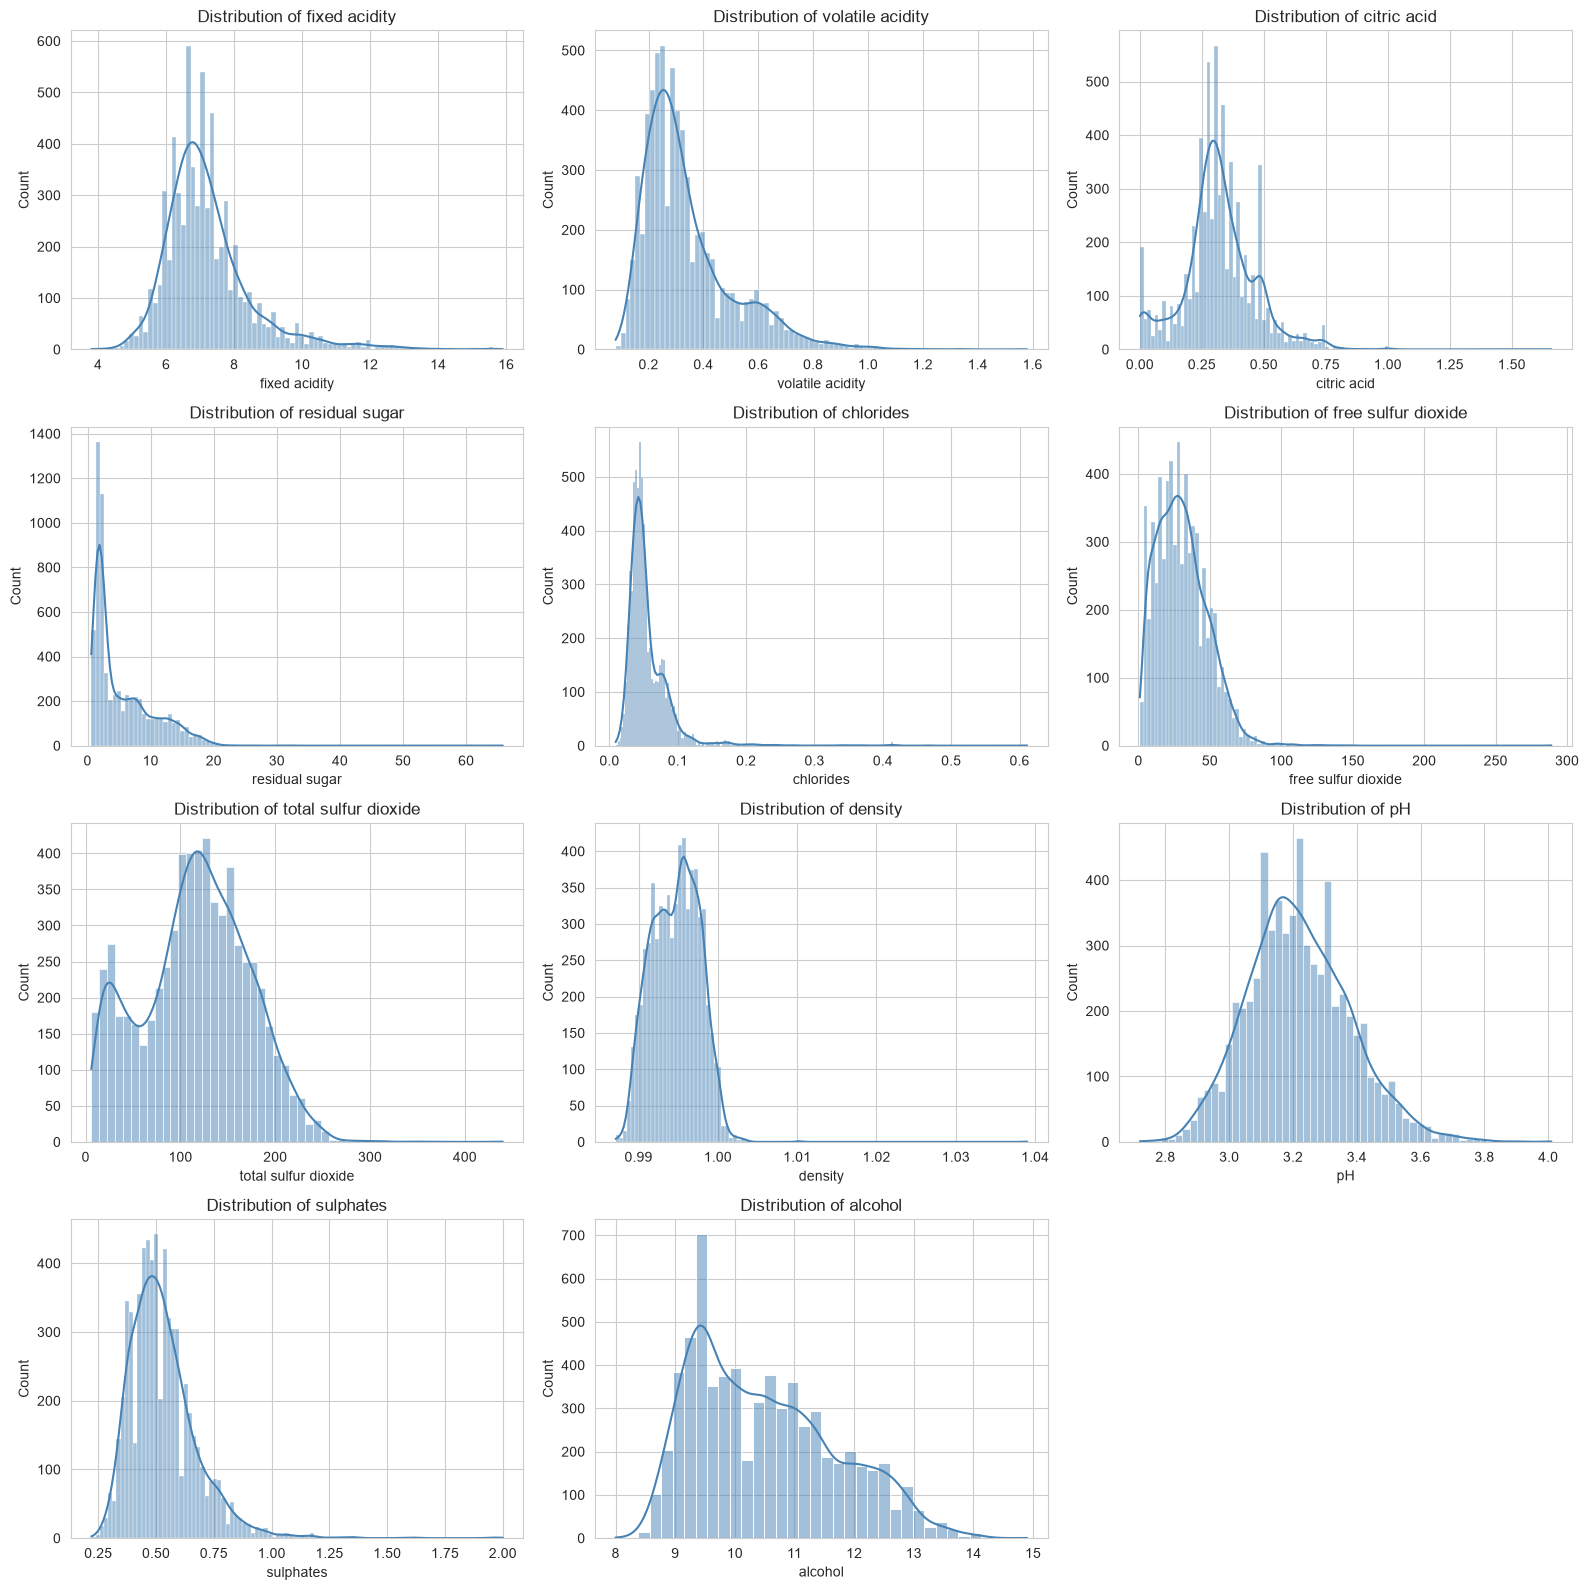

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop('quality')

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
for ax in axes[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


**Observation:** Most features (`residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`) are right-skewed with long tails, which is expected for chemical concentration measurements and suggests scaling (not just centering) is important before distance-based models like KNN and SVM.

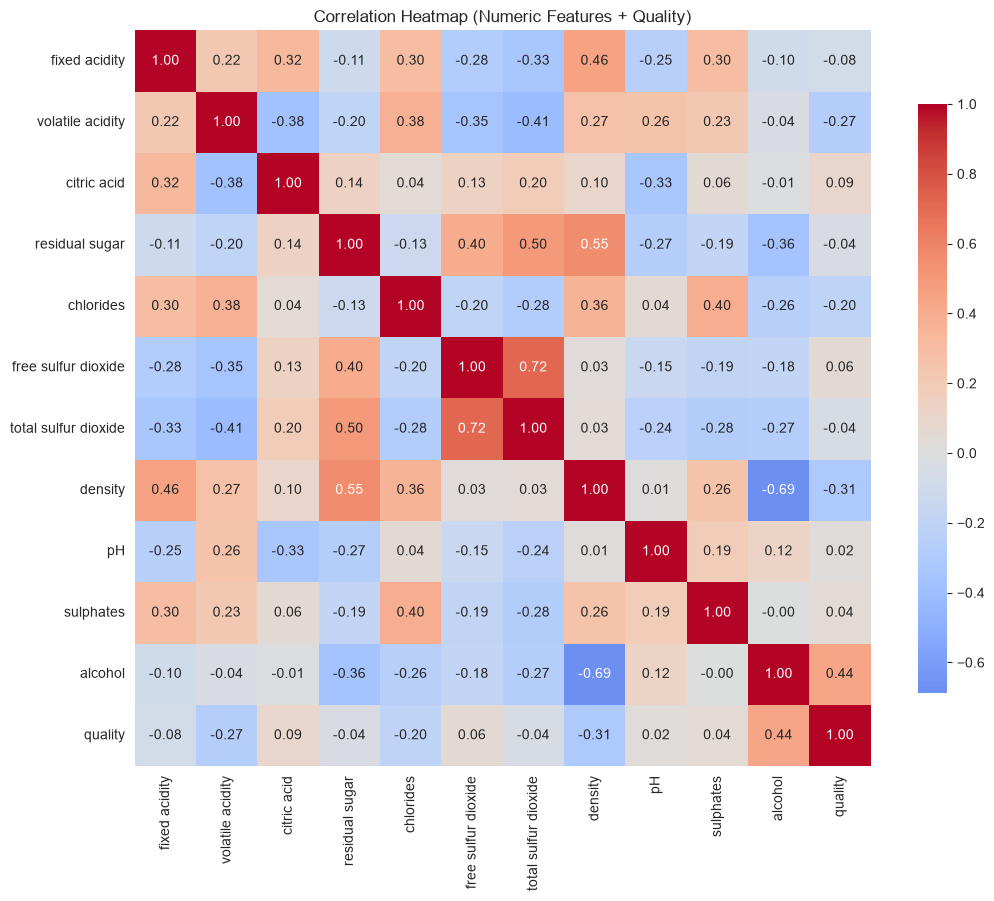

In [4]:
plt.figure(figsize=(11, 9))
corr = df[numeric_cols.tolist() + ['quality']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numeric Features + Quality)')
plt.tight_layout()
plt.show()


**Observation:** `alcohol` has the strongest positive correlation with `quality`, while `density` and `volatile acidity` are the strongest negative correlates. `density` is also highly correlated with `residual sugar` and `alcohol`, flagging mild multicollinearity that linear models (Logistic Regression) should account for via regularisation.

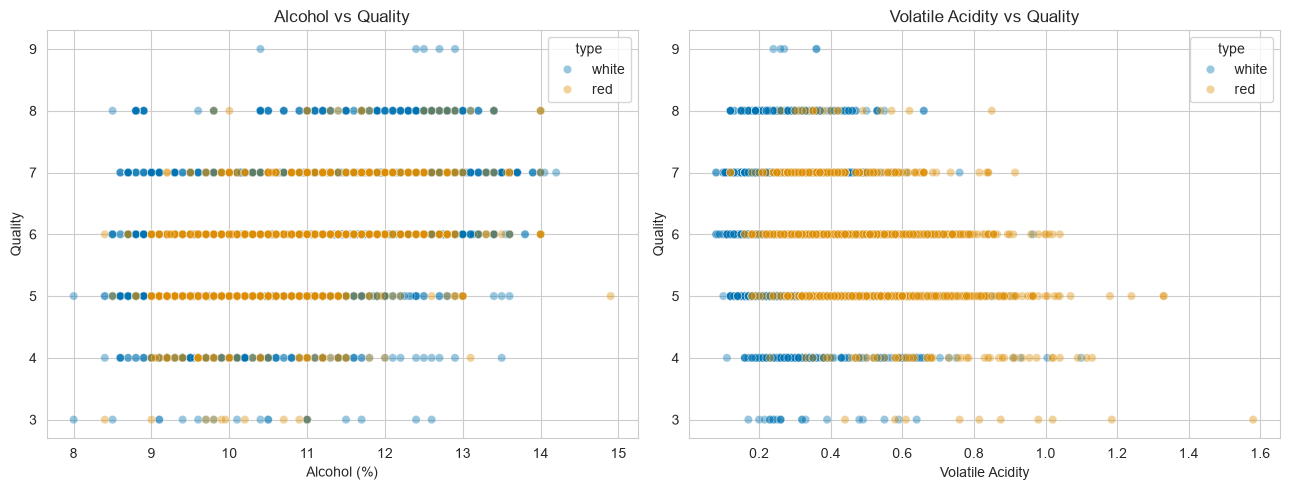

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='type', alpha=0.4, ax=axes[0])
axes[0].set_title('Alcohol vs Quality')
axes[0].set_xlabel('Alcohol (%)')
axes[0].set_ylabel('Quality')

sns.scatterplot(data=df, x='volatile acidity', y='quality', hue='type', alpha=0.4, ax=axes[1])
axes[1].set_title('Volatile Acidity vs Quality')
axes[1].set_xlabel('Volatile Acidity')
axes[1].set_ylabel('Quality')
plt.tight_layout()
plt.show()


**Observation:** Higher alcohol content trends toward higher quality scores, while higher volatile acidity (associated with a vinegary taste) trends toward lower quality — consistent with the correlation heatmap and with domain knowledge about wine faults.

## 4. Cleaning: Duplicates and Outliers

In [6]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f'Removed {before - df.shape[0]} duplicate rows. New shape: {df.shape}')

outlier_counts = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

display(pd.Series(outlier_counts, name='IQR outlier count').sort_values(ascending=False).to_frame())


Removed 1177 duplicate rows. New shape: (5320, 13)


,IQR outlier count
fixed acidity,304
volatile acidity,279
chlorides,237
sulphates,163
citric acid,143
residual sugar,141
pH,49
free sulfur dioxide,44
total sulfur dioxide,10
density,3


**Cleaning decision:** Exact duplicate rows are removed since they add no information and can bias cross-validation folds. IQR outliers are checked but **not removed** — features such as `residual sugar` and `total sulfur dioxide` naturally vary a lot between red and white wine, so many 'outliers' are genuine, informative wines rather than data-entry errors. Tree-based models are robust to them, and removing them would shrink an already modest dataset.

## 5. Feature Engineering

In [7]:
def add_features(frame):
    result = frame.copy()
    result['free_to_total_sulfur_ratio'] = result['free sulfur dioxide'] / (result['total sulfur dioxide'] + 1e-6)
    result['acidity_balance'] = result['fixed acidity'] + result['volatile acidity'] + result['citric acid']
    result['sugar_to_alcohol_ratio'] = result['residual sugar'] / (result['alcohol'] + 1e-6)
    result['alcohol_squared'] = result['alcohol'] ** 2
    return result

data = add_features(df)
data[['free_to_total_sulfur_ratio', 'acidity_balance', 'sugar_to_alcohol_ratio', 'alcohol_squared']].describe().T


,count,mean,std,min,25%,50%,75%,max
free_to_total_sulfur_ratio,5320.0,0.287000,0.125970,0.022727,0.201073,0.269021,0.350107,0.857143
acidity_balance,5320.0,7.877803,1.412845,4.130000,6.990000,7.590000,8.420000,17.045000
sugar_to_alcohol_ratio,5320.0,0.499737,0.475200,0.056604,0.163462,0.260000,0.724950,5.623931
alcohol_squared,5320.0,112.692663,25.833162,64.000000,90.250000,108.160000,129.960000,222.010000


**Justification:** `free_to_total_sulfur_ratio` captures how much of the preservative sulfur is still active (a known quality signal independent of the raw sulfur amount). `acidity_balance` summarises the three acidity measures into one, reducing redundancy for linear models. `sugar_to_alcohol_ratio` distinguishes sweet, low-alcohol wines from dry, high-alcohol ones — a combination the EDA correlations alone don't capture. `alcohol_squared` lets linear/logistic models approximate the mild non-linearity seen in the alcohol-vs-quality scatter plot.

## 6. Target Definition, Encoding, and Train/Test Split

In [8]:
# Binary target: quality >= 6 is treated as 'good' (>=6 covers the majority of mid/high scores)
data['quality_class'] = (data['quality'] >= 6).astype(int)
print(data['quality_class'].value_counts(normalize=True).rename('proportion'))

X = data.drop(columns=['quality', 'quality_class'])
y = data['quality_class']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric features:', len(numeric_features))
print('Categorical features:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


quality_class
1    0.626316
0    0.373684
Name: proportion, dtype: float64
Numeric features: 15
Categorical features: ['type']
Train shape: (4256, 16)  Test shape: (1064, 16)


## 7. Preprocessing Pipeline

In [9]:
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

def make_pipeline(model):
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
fitted_models = {}
confusion_matrices = {}

def evaluate_model(name, model):
    """Fit a model inside the shared preprocessing pipeline and record its metrics."""
    pipeline = make_pipeline(model)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]

    fitted_models[name] = pipeline
    confusion_matrices[name] = confusion_matrix(y_test, pred)
    results.append({
        'Model': name,
        'CV ROC-AUC': cv_scores.mean(),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-score (weighted)': f1_score(y_test, pred, average='weighted', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

    print(f'--- {name} ---')
    print(classification_report(y_test, pred, target_names=['quality < 6', 'quality >= 6']))
    sns.heatmap(confusion_matrices[name], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return pipeline


## 8. Classification — Part A (Review 1)
Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM — each trained and evaluated in its own cell.

### 8.1 Logistic Regression

--- Logistic Regression ---
              precision    recall  f1-score   support

 quality < 6       0.68      0.61      0.65       398
quality >= 6       0.78      0.83      0.80       666

    accuracy                           0.75      1064
   macro avg       0.73      0.72      0.73      1064
weighted avg       0.74      0.75      0.75      1064



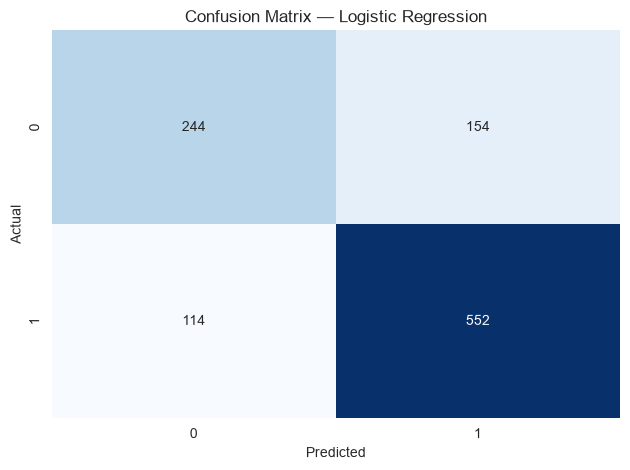

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['type','fixed acidity','volatile acidity',...,'acidity_balance', 'sugar_to_alcohol_ratio','alcohol_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [10]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
evaluate_model('Logistic Regression', log_reg)


### 8.2 K-Nearest Neighbors

--- KNN ---
              precision    recall  f1-score   support

 quality < 6       0.70      0.62      0.66       398
quality >= 6       0.79      0.84      0.81       666

    accuracy                           0.76      1064
   macro avg       0.74      0.73      0.73      1064
weighted avg       0.75      0.76      0.75      1064



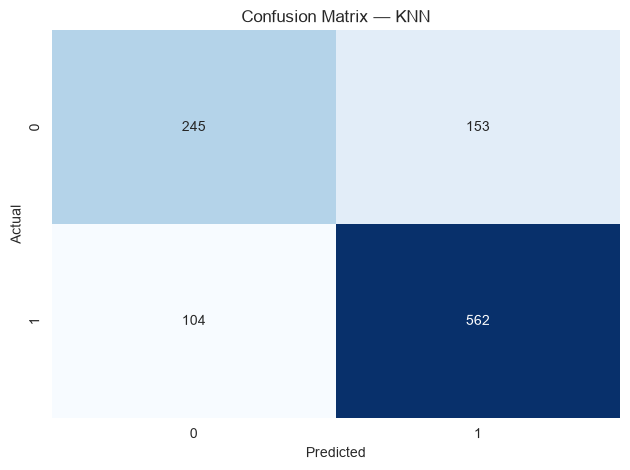

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['type','fixed acidity','volatile acidity',...,'acidity_balance', 'sugar_to_alcohol_ratio','alcohol_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [11]:
knn = KNeighborsClassifier(n_neighbors=15)
evaluate_model('KNN', knn)


### 8.3 Gaussian Naive Bayes

--- Gaussian Naive Bayes ---
              precision    recall  f1-score   support

 quality < 6       0.57      0.67      0.62       398
quality >= 6       0.78      0.70      0.74       666

    accuracy                           0.69      1064
   macro avg       0.68      0.69      0.68      1064
weighted avg       0.70      0.69      0.69      1064



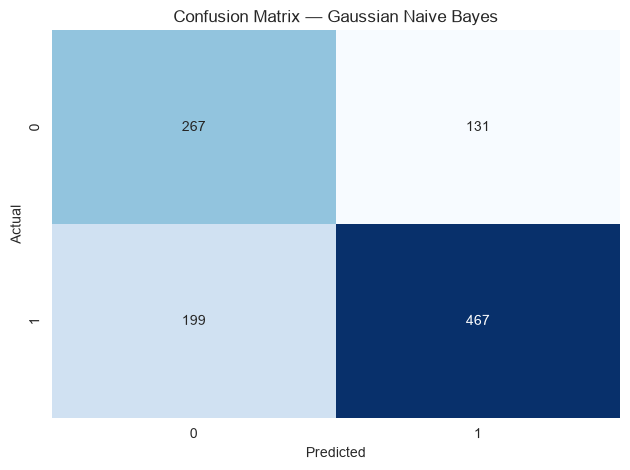

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['type','fixed acidity','volatile acidity',...,'acidity_balance', 'sugar_to_alcohol_ratio','alcohol_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [12]:
gnb = GaussianNB()
evaluate_model('Gaussian Naive Bayes', gnb)


### 8.4 Decision Tree Classifier

--- Decision Tree ---
              precision    recall  f1-score   support

 quality < 6       0.63      0.64      0.63       398
quality >= 6       0.78      0.78      0.78       666

    accuracy                           0.73      1064
   macro avg       0.71      0.71      0.71      1064
weighted avg       0.73      0.73      0.73      1064



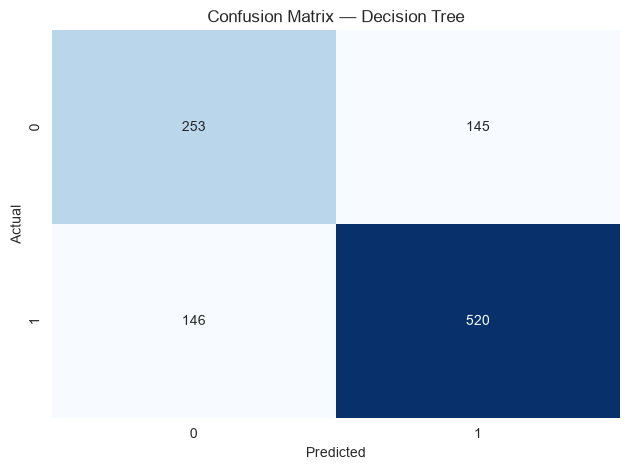

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['type','fixed acidity','volatile acidity',...,'acidity_balance', 'sugar_to_alcohol_ratio','alcohol_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [13]:
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
evaluate_model('Decision Tree', dt)


### 8.5 Support Vector Machine (SVC)

--- SVM ---
              precision    recall  f1-score   support

 quality < 6       0.72      0.66      0.69       398
quality >= 6       0.81      0.85      0.83       666

    accuracy                           0.78      1064
   macro avg       0.76      0.75      0.76      1064
weighted avg       0.77      0.78      0.77      1064



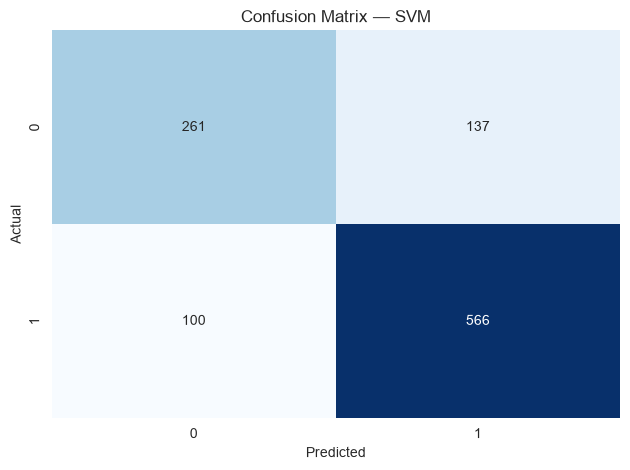

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['type','fixed acidity','volatile acidity',...,'acidity_balance', 'sugar_to_alcohol_ratio','alcohol_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [14]:
svm = SVC(C=2, kernel='rbf', probability=True, random_state=RANDOM_STATE)
evaluate_model('SVM', svm)


### 8.6 Part A — Preliminary Comparison Table

In [15]:
part_a_results = pd.DataFrame(results).sort_values('F1-score (weighted)', ascending=False).reset_index(drop=True)
display(part_a_results)


,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1-score (weighted),ROC-AUC
0,SVM,0.821032,0.777256,0.805121,0.849850,0.774836,0.832032
1,KNN,0.801210,0.758459,0.786014,0.843844,0.754822,0.817715
2,Logistic Regression,0.807722,0.748120,0.781870,0.828829,0.745129,0.814640
3,Decision Tree,0.734596,0.726504,0.781955,0.780781,0.726573,0.766764
4,Gaussian Naive Bayes,0.756723,0.689850,0.780936,0.701201,0.693712,0.756568
